# Performance Analytics

This notebook computes fund-level return, risk, benchmark, and scorecard metrics for the 40 mutual fund schemes using cleaned NAV, fund master, and benchmark index data.

Outputs:
- `data/processed/fund_scorecard.csv`
- `data/processed/alpha_beta.csv`
- `charts/performance/benchmark_comparison_top5.png`


In [9]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data" / "processed"
CHART_DIR = ROOT / "charts" / "performance"
CHART_DIR.mkdir(parents=True, exist_ok=True)

NAV_PATH = DATA_DIR / "cleaned_nav_history.csv"
FUND_MASTER_PATH = DATA_DIR / "cleaned_fund_master.csv"
BENCHMARK_PATH = DATA_DIR / "cleaned_benchmark_indices.csv"

RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Load and Prepare Data

In [10]:
nav = pd.read_csv(NAV_PATH, parse_dates=["date"])
fund_master = pd.read_csv(FUND_MASTER_PATH, parse_dates=["launch_date"])
benchmarks = pd.read_csv(BENCHMARK_PATH, parse_dates=["date"])

nav = nav.sort_values(["amfi_code", "date"]).copy()
fund_master["amfi_code"] = fund_master["amfi_code"].astype(nav["amfi_code"].dtype)

nav_wide = nav.pivot(index="date", columns="amfi_code", values="nav").sort_index()
benchmark_wide = (
    benchmarks.pivot(index="date", columns="index_name", values="close_value")
    .sort_index()
)

print(f"NAV rows: {len(nav):,}")
print(f"Schemes: {nav['amfi_code'].nunique()}")
print(f"NAV date range: {nav['date'].min().date()} to {nav['date'].max().date()}")
print(f"Benchmarks: {', '.join(benchmark_wide.columns)}")

NAV rows: 46,000
Schemes: 40
NAV date range: 2022-01-03 to 2026-05-29
Benchmarks: BSE_SMALLCAP, CRISIL_GILT, CRISIL_LIQUID, NIFTY100, NIFTY50, NIFTY500, NIFTY_MIDCAP150


## Daily Returns and Distribution Validation

count   45,960.0000
mean         0.0006
std          0.0103
min         -0.0581
1%          -0.0260
5%          -0.0163
25%         -0.0050
50%          0.0003
75%          0.0063
95%          0.0178
99%          0.0276
max          0.0647
dtype: float64


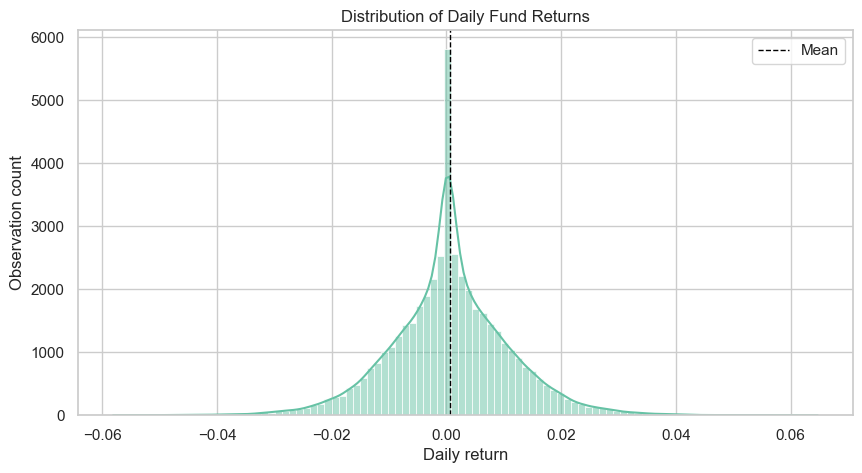

,amfi_code,count,mean,std,min,median,max,scheme_name,fund_house,category,plan
0,100016,1149,0.0001,0.0092,-0.0247,-0.0001,0.0321,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Regular
1,100025,1149,0.0002,0.0025,-0.0082,0.0001,0.0088,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,Regular
2,100033,1149,0.0011,0.0119,-0.0442,0.0011,0.0420,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular
3,101206,1149,0.0009,0.0092,-0.0381,0.0008,0.0340,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular
4,101207,1149,0.0004,0.0163,-0.0518,0.0002,0.0549,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular


In [11]:
daily_returns = nav_wide.pct_change()
benchmark_returns = benchmark_wide.pct_change()

return_distribution = (
    daily_returns.stack()
    .rename("daily_return")
    .reset_index()
    .groupby("amfi_code")["daily_return"]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .reset_index()
    .merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category", "plan"]], on="amfi_code", how="left")
)

all_daily_returns = daily_returns.stack().dropna()
distribution_summary = all_daily_returns.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print(distribution_summary)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(all_daily_returns, bins=100, kde=True, ax=ax)
ax.axvline(all_daily_returns.mean(), color="black", linestyle="--", linewidth=1, label="Mean")
ax.set_title("Distribution of Daily Fund Returns")
ax.set_xlabel("Daily return")
ax.set_ylabel("Observation count")
ax.legend()
plt.show()

return_distribution.head()

## CAGR for 1 Year, 3 Years, and 5 Years

In [12]:
def cagr_from_nav(nav_series: pd.Series, years: int) -> float:
    series = nav_series.dropna().sort_index()
    if series.empty:
        return np.nan

    end_date = series.index.max()
    target_start = end_date - pd.DateOffset(years=years)
    candidates = series.loc[series.index <= target_start]
    if candidates.empty:
        return np.nan

    start_nav = candidates.iloc[-1]
    end_nav = series.loc[end_date]
    return (end_nav / start_nav) ** (1 / years) - 1


def available_period_cagr(nav_series: pd.Series) -> float:
    series = nav_series.dropna().sort_index()
    elapsed_years = (series.index.max() - series.index.min()).days / 365.25
    if elapsed_years <= 0:
        return np.nan
    return (series.iloc[-1] / series.iloc[0]) ** (1 / elapsed_years) - 1


cagr_rows = []
for amfi_code, series in nav_wide.items():
    cagr_rows.append(
        {
            "amfi_code": amfi_code,
            "cagr_1yr_pct": cagr_from_nav(series, 1) * 100,
            "cagr_3yr_pct": cagr_from_nav(series, 3) * 100,
            "cagr_5yr_pct": cagr_from_nav(series, 5) * 100,
            "cagr_available_period_pct": available_period_cagr(series) * 100,
            "available_start_date": series.dropna().index.min().date(),
            "available_end_date": series.dropna().index.max().date(),
        }
    )

cagr_table = (
    pd.DataFrame(cagr_rows)
    .merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category", "plan"]], on="amfi_code", how="left")
    .sort_values("cagr_3yr_pct", ascending=False)
)

if cagr_table["cagr_5yr_pct"].isna().all():
    print("True 5-year CAGR is unavailable because NAV history starts after the required 5-year lookback date.")

cagr_table.head(10)

True 5-year CAGR is unavailable because NAV history starts after the required 5-year lookback date.


,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,cagr_available_period_pct,available_start_date,available_end_date,scheme_name,fund_house,category,plan
16,119094,22.2611,35.1118,NaN,28.2144,2022-01-03,2026-05-29,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Regular
34,148567,20.3607,34.0009,NaN,30.9741,2022-01-03,2026-05-29,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Regular
24,120504,13.0643,32.4874,NaN,23.2951,2022-01-03,2026-05-29,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,Direct
2,100033,53.2324,32.4425,NaN,30.1232,2022-01-03,2026-05-29,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular
25,120505,29.6047,31.7775,NaN,32.8274,2022-01-03,2026-05-29,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Regular
19,119551,60.4373,30.4565,NaN,25.8047,2022-01-03,2026-05-29,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular
30,120843,26.6571,29.5828,NaN,30.9075,2022-01-03,2026-05-29,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Regular
36,148569,39.7518,29.1789,NaN,31.9495,2022-01-03,2026-05-29,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,Regular
3,101206,47.9241,28.9677,NaN,23.5384,2022-01-03,2026-05-29,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular
39,149324,65.1387,27.0004,NaN,32.2874,2022-01-03,2026-05-29,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Regular


## Risk Metrics, Alpha/Beta, and Maximum Drawdown

In [13]:
def annualized_return(returns: pd.Series) -> float:
    clean = returns.dropna()
    if clean.empty:
        return np.nan
    return (1 + clean).prod() ** (TRADING_DAYS / len(clean)) - 1


def sharpe_ratio(returns: pd.Series) -> float:
    clean = returns.dropna()
    if clean.std(ddof=1) == 0 or clean.empty:
        return np.nan
    excess_daily = clean.mean() - (RISK_FREE_RATE / TRADING_DAYS)
    return excess_daily / clean.std(ddof=1) * np.sqrt(TRADING_DAYS)


def sortino_ratio(returns: pd.Series) -> float:
    clean = returns.dropna()
    downside = clean[clean < 0]
    if downside.std(ddof=1) == 0 or downside.empty:
        return np.nan
    excess_daily = clean.mean() - (RISK_FREE_RATE / TRADING_DAYS)
    return excess_daily / downside.std(ddof=1) * np.sqrt(TRADING_DAYS)


def max_drawdown_details(nav_series: pd.Series) -> dict:
    series = nav_series.dropna().sort_index()
    running_max = series.cummax()
    drawdown = series / running_max - 1
    trough_date = drawdown.idxmin()
    peak_date = series.loc[:trough_date].idxmax()
    recovery = series.loc[trough_date:][series.loc[trough_date:] >= series.loc[peak_date]]
    recovery_date = recovery.index[0] if not recovery.empty else pd.NaT
    return {
        "max_drawdown_pct": drawdown.min() * 100,
        "max_drawdown_peak_date": peak_date,
        "max_drawdown_trough_date": trough_date,
        "max_drawdown_recovery_date": recovery_date,
    }


nifty100_returns = benchmark_returns["NIFTY100"].dropna()

metric_rows = []
for amfi_code, returns in daily_returns.items():
    fund_returns = returns.dropna()
    aligned = pd.concat([fund_returns.rename("fund_return"), nifty100_returns.rename("nifty100_return")], axis=1).dropna()

    if len(aligned) >= 2:
        regression = linregress(aligned["nifty100_return"], aligned["fund_return"])
        beta = regression.slope
        alpha = regression.intercept * TRADING_DAYS
        r_value = regression.rvalue
        p_value = regression.pvalue
    else:
        beta = alpha = r_value = p_value = np.nan

    row = {
        "amfi_code": amfi_code,
        "annualized_return_pct": annualized_return(fund_returns) * 100,
        "annualized_volatility_pct": fund_returns.std(ddof=1) * np.sqrt(TRADING_DAYS) * 100,
        "sharpe_ratio": sharpe_ratio(fund_returns),
        "sortino_ratio": sortino_ratio(fund_returns),
        "alpha_pct": alpha * 100,
        "beta": beta,
        "r_squared": r_value ** 2 if pd.notna(r_value) else np.nan,
        "regression_p_value": p_value,
    }
    row.update(max_drawdown_details(nav_wide[amfi_code]))
    metric_rows.append(row)

metrics = (
    pd.DataFrame(metric_rows)
    .merge(cagr_table[["amfi_code", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct", "cagr_available_period_pct"]], on="amfi_code", how="left")
    .merge(fund_master[["amfi_code", "scheme_name", "fund_house", "category", "plan", "benchmark", "expense_ratio_pct"]], on="amfi_code", how="left")
)

alpha_beta = metrics[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "plan",
        "alpha_pct",
        "beta",
        "r_squared",
        "regression_p_value",
    ]
].sort_values("alpha_pct", ascending=False)

alpha_beta.to_csv(DATA_DIR / "alpha_beta.csv", index=False)
alpha_beta.head(10)

,amfi_code,scheme_name,fund_house,category,plan,alpha_pct,beta,r_squared,regression_p_value
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,30.3370,-0.0232,0.0001,0.6872
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Regular,30.0579,0.0115,0.0000,0.8405
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Regular,29.2636,0.0005,0.0000,0.9901
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,28.2704,0.0181,0.0002,0.6543
30,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Regular,27.3305,-0.0228,0.0003,0.5305
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular,27.1954,0.0051,0.0000,0.9064
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,26.9838,0.0237,0.0005,0.4664
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,Regular,26.5986,-0.0025,0.0000,0.9505
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Regular,26.0767,-0.0663,0.0019,0.1360
19,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,23.2010,-0.0318,0.0009,0.3131


## Fund Scorecard

In [14]:
def percentile_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    return series.rank(ascending=higher_is_better, pct=True) * 100


scorecard = metrics.copy()
scorecard["return_3yr_score"] = percentile_score(scorecard["cagr_3yr_pct"], higher_is_better=True)
scorecard["sharpe_score"] = percentile_score(scorecard["sharpe_ratio"], higher_is_better=True)
scorecard["alpha_score"] = percentile_score(scorecard["alpha_pct"], higher_is_better=True)
scorecard["expense_ratio_score"] = percentile_score(scorecard["expense_ratio_pct"], higher_is_better=False)
scorecard["max_drawdown_abs_pct"] = scorecard["max_drawdown_pct"].abs()
scorecard["max_drawdown_score"] = percentile_score(scorecard["max_drawdown_abs_pct"], higher_is_better=False)

scorecard["fund_score"] = (
    0.30 * scorecard["return_3yr_score"]
    + 0.25 * scorecard["sharpe_score"]
    + 0.20 * scorecard["alpha_score"]
    + 0.15 * scorecard["expense_ratio_score"]
    + 0.10 * scorecard["max_drawdown_score"]
).round(2)

scorecard["score_rank"] = scorecard["fund_score"].rank(ascending=False, method="dense").astype(int)

scorecard_cols = [
    "score_rank",
    "fund_score",
    "amfi_code",
    "scheme_name",
    "fund_house",
    "category",
    "plan",
    "cagr_1yr_pct",
    "cagr_3yr_pct",
    "cagr_5yr_pct",
    "cagr_available_period_pct",
    "sharpe_ratio",
    "sortino_ratio",
    "alpha_pct",
    "beta",
    "annualized_return_pct",
    "annualized_volatility_pct",
    "expense_ratio_pct",
    "max_drawdown_pct",
    "max_drawdown_peak_date",
    "max_drawdown_trough_date",
    "max_drawdown_recovery_date",
    "return_3yr_score",
    "sharpe_score",
    "alpha_score",
    "expense_ratio_score",
    "max_drawdown_score",
]

fund_scorecard = scorecard[scorecard_cols].sort_values(["score_rank", "fund_score"], ascending=[True, False])
fund_scorecard.to_csv(DATA_DIR / "fund_scorecard.csv", index=False)
fund_scorecard.head(10)

,score_rank,fund_score,amfi_code,scheme_name,fund_house,category,plan,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,cagr_available_period_pct,sharpe_ratio,sortino_ratio,alpha_pct,beta,annualized_return_pct,annualized_volatility_pct,expense_ratio_pct,max_drawdown_pct,max_drawdown_peak_date,max_drawdown_trough_date,max_drawdown_recovery_date,return_3yr_score,sharpe_score,alpha_score,expense_ratio_score,max_drawdown_score
34,1,86.2500,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,20.3607,34.0009,NaN,30.9741,1.4483,2.3856,26.9838,0.0237,29.7414,14.1937,1.4600,-11.2657,2023-07-11,2023-10-20,2024-02-21,97.5000,100.0000,85.0000,45.0000,82.5000
25,2,82.2500,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Regular,29.6047,31.7775,NaN,32.8274,1.1801,2.0294,29.2636,0.0005,31.5124,19.2909,1.3600,-18.1885,2024-10-24,2025-01-23,2025-03-07,90.0000,90.0000,95.0000,65.0000,40.0000
30,3,82.0000,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Regular,26.6571,29.5828,NaN,30.9075,1.3067,2.3643,27.3305,-0.0228,29.6776,15.8870,1.4500,-12.9740,2022-03-07,2022-04-13,2022-09-22,85.0000,97.5000,90.0000,47.5000,70.0000
2,4,80.7500,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular,53.2324,32.4425,NaN,30.1232,1.0937,1.8291,27.1954,0.0051,28.9279,18.9367,1.3800,-16.2172,2022-03-11,2022-05-12,2022-07-27,92.5000,85.0000,87.5000,60.0000,52.5000
24,5,80.0000,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,Direct,13.0643,32.4874,NaN,23.2951,1.0265,1.8053,21.1948,0.0162,22.3935,14.3638,0.8000,-12.5883,2022-10-04,2023-05-30,2023-07-11,95.0000,77.5000,70.0000,72.5000,72.5000
16,6,77.0000,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Regular,22.2611,35.1118,NaN,28.2144,0.9982,1.7038,26.0767,-0.0663,27.1025,19.4071,1.3800,-20.9609,2022-04-14,2022-08-11,2023-01-17,100.0000,75.0000,80.0000,60.0000,32.5000
19,7,74.8100,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,60.4373,30.4565,NaN,25.8047,1.2083,2.1403,23.2010,-0.0318,24.7966,13.7414,1.5400,-15.0124,2023-08-24,2024-02-05,2025-01-08,87.5000,92.5000,77.5000,26.2500,60.0000
36,8,73.6900,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,39.7518,29.1789,NaN,31.9495,1.2349,2.1469,28.2704,0.0181,30.6736,17.6740,1.6000,-16.3967,2023-08-10,2023-10-20,2024-04-10,82.5000,95.0000,92.5000,11.2500,50.0000
3,9,68.1900,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,47.9241,28.9677,NaN,23.5384,1.0272,1.7996,21.3998,0.0211,22.6265,14.5682,1.6000,-11.2916,2023-04-24,2023-07-05,2023-09-28,80.0000,80.0000,72.5000,11.2500,80.0000
21,10,67.3800,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,82.7761,26.6699,NaN,32.4235,0.9453,1.6753,30.3370,-0.0232,31.1266,25.1406,1.4300,-28.7060,2024-08-28,2025-05-14,2025-09-29,72.5000,67.5000,100.0000,50.0000,12.5000


## Benchmark Comparison and Tracking Error

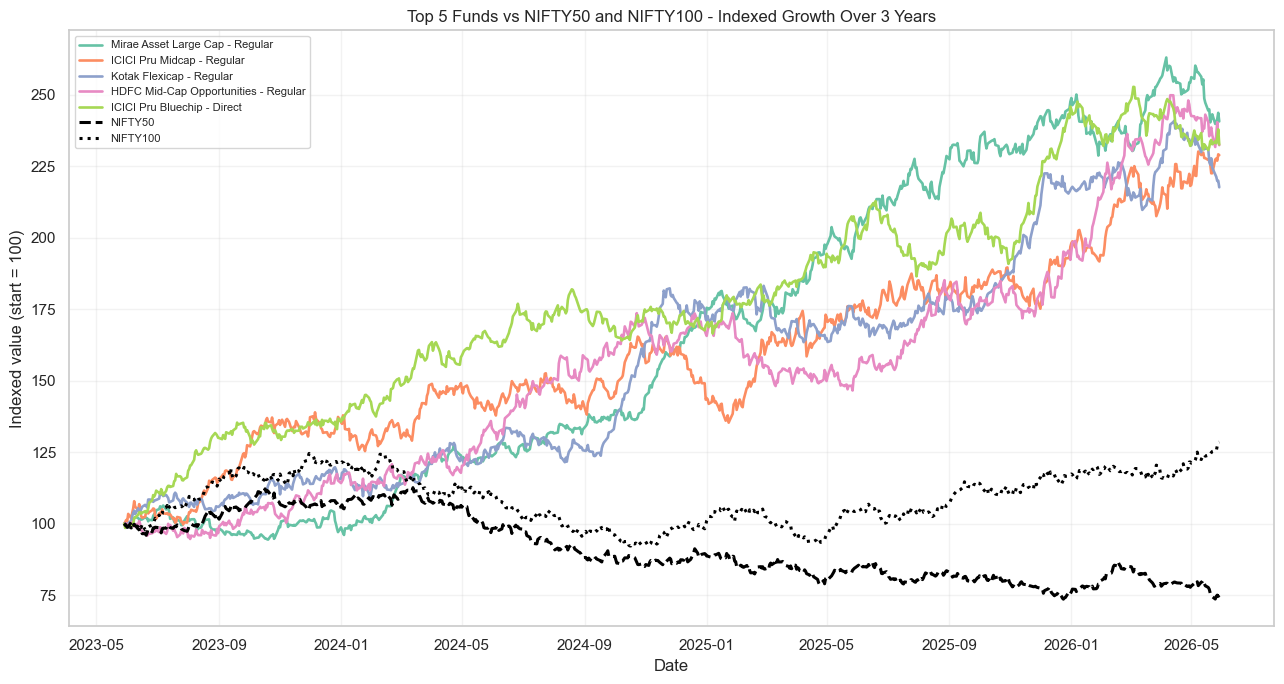

Saved chart to charts\performance\benchmark_comparison_top5.png


,amfi_code,scheme_name,benchmark,tracking_error_pct
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,19.1817
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,18.7867
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,22.8311
3,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.2515
4,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.4946
5,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.6410
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,22.8081
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,22.4838
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY50,18.8360
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,18.7312


In [15]:
top5_codes = fund_scorecard.head(5)["amfi_code"].tolist()
end_date = nav_wide.index.max()
start_3yr = end_date - pd.DateOffset(years=3)

top5_nav = nav_wide.loc[nav_wide.index >= start_3yr, top5_codes].dropna(how="all")
top_benchmarks = benchmark_wide.loc[benchmark_wide.index >= start_3yr, ["NIFTY50", "NIFTY100"]]

indexed_funds = top5_nav / top5_nav.iloc[0] * 100
indexed_benchmarks = top_benchmarks / top_benchmarks.iloc[0] * 100

tracking_rows = []
for amfi_code in top5_codes:
    fund_return = daily_returns.loc[daily_returns.index >= start_3yr, amfi_code]
    scheme_name = fund_master.loc[fund_master["amfi_code"] == amfi_code, "scheme_name"].iloc[0]
    for benchmark_name in ["NIFTY50", "NIFTY100"]:
        aligned = pd.concat(
            [
                fund_return.rename("fund_return"),
                benchmark_returns.loc[benchmark_returns.index >= start_3yr, benchmark_name].rename("benchmark_return"),
            ],
            axis=1,
        ).dropna()
        tracking_error = (aligned["fund_return"] - aligned["benchmark_return"]).std(ddof=1) * np.sqrt(TRADING_DAYS)
        tracking_rows.append(
            {
                "amfi_code": amfi_code,
                "scheme_name": scheme_name,
                "benchmark": benchmark_name,
                "tracking_error_pct": tracking_error * 100,
            }
        )

tracking_error_table = pd.DataFrame(tracking_rows)

label_map = fund_master.set_index("amfi_code")["scheme_name"].to_dict()
fig, ax = plt.subplots(figsize=(13, 7))
for amfi_code in top5_codes:
    short_name = label_map[amfi_code].replace(" - Growth", "").replace(" Fund", "")
    ax.plot(indexed_funds.index, indexed_funds[amfi_code], linewidth=1.9, label=short_name)

for benchmark_name, line_style in [("NIFTY50", "--"), ("NIFTY100", ":")]:
    ax.plot(indexed_benchmarks.index, indexed_benchmarks[benchmark_name], color="black", linestyle=line_style, linewidth=2.2, label=benchmark_name)

ax.set_title("Top 5 Funds vs NIFTY50 and NIFTY100 - Indexed Growth Over 3 Years")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed value (start = 100)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.25)
fig.tight_layout()
chart_path = CHART_DIR / "benchmark_comparison_top5.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved chart to {chart_path.relative_to(ROOT)}")
tracking_error_table

## Ranked Outputs

In [16]:
print("Top 10 funds by score")
display(fund_scorecard.head(10))

print("Top 10 funds by Sharpe Ratio")
display(fund_scorecard.sort_values("sharpe_ratio", ascending=False).head(10))

print("Worst maximum drawdowns")
display(fund_scorecard.sort_values("max_drawdown_pct").head(10))

print("Tracking error for top 5 funds")
display(tracking_error_table.sort_values(["benchmark", "tracking_error_pct"]))

Top 10 funds by score


,score_rank,fund_score,amfi_code,scheme_name,fund_house,category,plan,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,cagr_available_period_pct,sharpe_ratio,sortino_ratio,alpha_pct,beta,annualized_return_pct,annualized_volatility_pct,expense_ratio_pct,max_drawdown_pct,max_drawdown_peak_date,max_drawdown_trough_date,max_drawdown_recovery_date,return_3yr_score,sharpe_score,alpha_score,expense_ratio_score,max_drawdown_score
34,1,86.2500,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,20.3607,34.0009,NaN,30.9741,1.4483,2.3856,26.9838,0.0237,29.7414,14.1937,1.4600,-11.2657,2023-07-11,2023-10-20,2024-02-21,97.5000,100.0000,85.0000,45.0000,82.5000
25,2,82.2500,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Regular,29.6047,31.7775,NaN,32.8274,1.1801,2.0294,29.2636,0.0005,31.5124,19.2909,1.3600,-18.1885,2024-10-24,2025-01-23,2025-03-07,90.0000,90.0000,95.0000,65.0000,40.0000
30,3,82.0000,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Regular,26.6571,29.5828,NaN,30.9075,1.3067,2.3643,27.3305,-0.0228,29.6776,15.8870,1.4500,-12.9740,2022-03-07,2022-04-13,2022-09-22,85.0000,97.5000,90.0000,47.5000,70.0000
2,4,80.7500,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular,53.2324,32.4425,NaN,30.1232,1.0937,1.8291,27.1954,0.0051,28.9279,18.9367,1.3800,-16.2172,2022-03-11,2022-05-12,2022-07-27,92.5000,85.0000,87.5000,60.0000,52.5000
24,5,80.0000,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,Direct,13.0643,32.4874,NaN,23.2951,1.0265,1.8053,21.1948,0.0162,22.3935,14.3638,0.8000,-12.5883,2022-10-04,2023-05-30,2023-07-11,95.0000,77.5000,70.0000,72.5000,72.5000
16,6,77.0000,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,Regular,22.2611,35.1118,NaN,28.2144,0.9982,1.7038,26.0767,-0.0663,27.1025,19.4071,1.3800,-20.9609,2022-04-14,2022-08-11,2023-01-17,100.0000,75.0000,80.0000,60.0000,32.5000
19,7,74.8100,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,60.4373,30.4565,NaN,25.8047,1.2083,2.1403,23.2010,-0.0318,24.7966,13.7414,1.5400,-15.0124,2023-08-24,2024-02-05,2025-01-08,87.5000,92.5000,77.5000,26.2500,60.0000
36,8,73.6900,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,39.7518,29.1789,NaN,31.9495,1.2349,2.1469,28.2704,0.0181,30.6736,17.6740,1.6000,-16.3967,2023-08-10,2023-10-20,2024-04-10,82.5000,95.0000,92.5000,11.2500,50.0000
3,9,68.1900,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,47.9241,28.9677,NaN,23.5384,1.0272,1.7996,21.3998,0.0211,22.6265,14.5682,1.6000,-11.2916,2023-04-24,2023-07-05,2023-09-28,80.0000,80.0000,72.5000,11.2500,80.0000
21,10,67.3800,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,82.7761,26.6699,NaN,32.4235,0.9453,1.6753,30.3370,-0.0232,31.1266,25.1406,1.4300,-28.7060,2024-08-28,2025-05-14,2025-09-29,72.5000,67.5000,100.0000,50.0000,12.5000


Top 10 funds by Sharpe Ratio


,score_rank,fund_score,amfi_code,scheme_name,fund_house,category,plan,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,cagr_available_period_pct,sharpe_ratio,sortino_ratio,alpha_pct,beta,annualized_return_pct,annualized_volatility_pct,expense_ratio_pct,max_drawdown_pct,max_drawdown_peak_date,max_drawdown_trough_date,max_drawdown_recovery_date,return_3yr_score,sharpe_score,alpha_score,expense_ratio_score,max_drawdown_score
34,1,86.2500,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,20.3607,34.0009,NaN,30.9741,1.4483,2.3856,26.9838,0.0237,29.7414,14.1937,1.4600,-11.2657,2023-07-11,2023-10-20,2024-02-21,97.5000,100.0000,85.0000,45.0000,82.5000
30,3,82.0000,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Regular,26.6571,29.5828,NaN,30.9075,1.3067,2.3643,27.3305,-0.0228,29.6776,15.8870,1.4500,-12.9740,2022-03-07,2022-04-13,2022-09-22,85.0000,97.5000,90.0000,47.5000,70.0000
36,8,73.6900,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,Regular,39.7518,29.1789,NaN,31.9495,1.2349,2.1469,28.2704,0.0181,30.6736,17.6740,1.6000,-16.3967,2023-08-10,2023-10-20,2024-04-10,82.5000,95.0000,92.5000,11.2500,50.0000
19,7,74.8100,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,60.4373,30.4565,NaN,25.8047,1.2083,2.1403,23.2010,-0.0318,24.7966,13.7414,1.5400,-15.0124,2023-08-24,2024-02-05,2025-01-08,87.5000,92.5000,77.5000,26.2500,60.0000
25,2,82.2500,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,Regular,29.6047,31.7775,NaN,32.8274,1.1801,2.0294,29.2636,0.0005,31.5124,19.2909,1.3600,-18.1885,2024-10-24,2025-01-23,2025-03-07,90.0000,90.0000,95.0000,65.0000,40.0000
38,11,66.7500,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,Regular,21.4812,26.8700,NaN,29.5811,1.1321,1.8751,26.5986,-0.0025,28.4096,17.7462,1.6100,-17.2481,2022-06-06,2022-10-24,2022-12-20,75.0000,87.5000,82.5000,7.5000,47.5000
2,4,80.7500,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,Regular,53.2324,32.4425,NaN,30.1232,1.0937,1.8291,27.1954,0.0051,28.9279,18.9367,1.3800,-16.2172,2022-03-11,2022-05-12,2022-07-27,92.5000,85.0000,87.5000,60.0000,52.5000
9,13,66.5600,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity,Regular,33.9810,22.6524,NaN,24.0495,1.0817,1.8501,21.8294,-0.0084,23.1161,14.1484,1.5100,-17.4141,2024-01-02,2024-07-19,2025-05-21,67.5000,82.5000,75.0000,41.2500,45.0000
3,9,68.1900,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,47.9241,28.9677,NaN,23.5384,1.0272,1.7996,21.3998,0.0211,22.6265,14.5682,1.6000,-11.2916,2023-04-24,2023-07-05,2023-09-28,80.0000,80.0000,72.5000,11.2500,80.0000
24,5,80.0000,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Equity,Direct,13.0643,32.4874,NaN,23.2951,1.0265,1.8053,21.1948,0.0162,22.3935,14.3638,0.8000,-12.5883,2022-10-04,2023-05-30,2023-07-11,95.0000,77.5000,70.0000,72.5000,72.5000


Worst maximum drawdowns


,score_rank,fund_score,amfi_code,scheme_name,fund_house,category,plan,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,cagr_available_period_pct,sharpe_ratio,sortino_ratio,alpha_pct,beta,annualized_return_pct,annualized_volatility_pct,expense_ratio_pct,max_drawdown_pct,max_drawdown_peak_date,max_drawdown_trough_date,max_drawdown_recovery_date,return_3yr_score,sharpe_score,alpha_score,expense_ratio_score,max_drawdown_score
22,35,23.9400,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Direct,13.9478,-1.3374,NaN,2.0545,-0.0572,-0.0944,4.8824,0.0620,1.9818,24.9501,0.7200,-52.5742,2023-01-17,2025-10-28,NaT,7.5000,22.5000,12.5000,88.7500,2.5000
17,38,17.2500,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Regular,-42.7976,-11.7058,NaN,1.5215,-0.0760,-0.1282,4.8016,-0.0670,1.4678,25.0666,1.3800,-51.6778,2025-05-22,2026-05-11,NaT,2.5000,20.0000,10.0000,60.0000,5.0000
4,37,22.0600,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Regular,-23.9860,-4.1524,NaN,7.9388,0.1627,0.2766,10.8971,-0.0653,7.6502,25.7973,1.5300,-35.4469,2024-11-21,2026-05-11,NaT,5.0000,32.5000,35.0000,31.2500,7.5000
39,12,66.6900,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Regular,65.1387,27.0004,NaN,32.2874,0.9498,1.6198,30.0579,0.0115,30.9965,24.8402,1.5200,-31.1719,2024-05-03,2025-01-03,2025-06-13,77.5000,70.0000,97.5000,36.2500,10.0000
21,10,67.3800,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Regular,82.7761,26.6699,NaN,32.4235,0.9453,1.6753,30.3370,-0.0232,31.1266,25.1406,1.4300,-28.7060,2024-08-28,2025-05-14,2025-09-29,72.5000,67.5000,100.0000,50.0000,12.5000
7,40,14.3100,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,Regular,-16.7975,-0.7674,NaN,1.1717,-0.2058,-0.3472,2.8969,-0.0421,1.1304,18.1346,1.5100,-28.0011,2025-01-07,2026-04-27,NaT,10.0000,12.5000,2.5000,41.2500,15.0000
0,39,14.3800,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Equity,Regular,-2.2243,1.2926,NaN,2.6371,-0.2015,-0.3510,3.7476,-0.0583,2.5435,14.5481,1.5500,-24.7344,2022-03-30,2022-09-15,2023-03-14,15.0000,15.0000,5.0000,22.5000,17.5000
29,34,27.6200,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity,Regular,22.5020,7.7560,NaN,6.7015,0.0760,0.1247,7.8044,0.0181,6.4593,17.8947,1.5600,-24.0035,2023-11-09,2024-10-17,2025-10-14,32.5000,27.5000,30.0000,20.0000,20.0000
11,29,38.3100,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Regular,15.8112,8.0079,NaN,16.3735,0.4484,0.7460,17.5007,0.1035,15.7567,25.2415,1.5300,-23.3449,2025-04-09,2026-02-20,2026-04-15,35.0000,37.5000,57.5000,31.2500,22.5000
15,23,47.6200,119093,Axis Bluechip Fund - Direct - Growth,Axis Mutual Fund,Equity,Direct,19.7667,20.8168,NaN,7.8976,0.1296,0.2211,8.2328,0.0259,7.6105,13.9833,0.7500,-21.7514,2022-02-24,2023-05-22,2023-12-26,62.5000,30.0000,32.5000,82.5000,25.0000


Tracking error for top 5 funds


,amfi_code,scheme_name,benchmark,tracking_error_pct
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,18.7312
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,18.7867
5,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.6410
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,22.4838
3,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.2515
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY50,18.8360
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,19.1817
4,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.4946
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,22.8081
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,22.8311
